In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

try:
    # --- 1. Carga de Datos ---
    # (Asegúrate de que el nombre del archivo sea correcto)
    df_so = pd.read_csv('datasets/stack overflow/stack_overflow_2023.csv') 
    
    print(f"Stack Overflow cargado: {df_so.shape[0]} filas, {df_so.shape[1]} columnas.")

    # --- 2. Inspección Inicial ---
    
    # Lista de columnas que nos interesan para el modelo
    columns_of_interest = [
        'ConvertedCompYearly', # Nuestro target (y)
        'YearsCode',           # Experiencia
        'EdLevel',             # Educación
        'LanguageHaveWorkedWith',  # Habilidades
        'DatabaseHaveWorkedWith',  # Habilidades
        'PlatformHaveWorkedWith',  # Habilidades
        'DevType'              # Rol
    ]
    
    # (Añadimos 'MainBranch' por si 'DevType' tiene muchos nulos)
    columns_of_interest.append('MainBranch')

    # Filtramos el DataFrame para solo ver estas columnas
    df_so_subset = df_so[columns_of_interest]
    
    print("\n--- Inspección de Columnas Clave ---")
    print(df_so_subset.info())

    print("\n--- Ejemplo de Datos (Primeras filas) ---")
    print(df_so_subset.head())
    
    print("\n--- Conteo de Nulos (Nuestro primer desafío) ---")
    print(df_so_subset.isnull().sum().sort_values(ascending=False))

except FileNotFoundError:
    print("--- ¡ERROR! ---")
    print("No se encontró el archivo 'stack_overflow_2023.csv'. Asegúrate de que esté en la carpeta correcta.")
except Exception as e:
    print(f"Ocurrió un error: {e}")

Stack Overflow cargado: 89184 filas, 84 columnas.

--- Inspección de Columnas Clave ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 89184 entries, 0 to 89183
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   ConvertedCompYearly     48019 non-null  float64
 1   YearsCode               87435 non-null  object 
 2   EdLevel                 87973 non-null  object 
 3   LanguageHaveWorkedWith  87140 non-null  object 
 4   DatabaseHaveWorkedWith  73435 non-null  object 
 5   PlatformHaveWorkedWith  63628 non-null  object 
 6   DevType                 76872 non-null  object 
 7   MainBranch              89184 non-null  object 
dtypes: float64(1), object(7)
memory usage: 5.4+ MB
None

--- Ejemplo de Datos (Primeras filas) ---
   ConvertedCompYearly YearsCode  \
0                  NaN       NaN   
1             285000.0        18   
2             250000.0        27   
3             156000.0        

In [3]:
try:
    print(f"Tamaño original de df_so: {df_so.shape}")

    # 1. Filtrar solo por desarrolladores profesionales
    df_so_clean = df_so[df_so['MainBranch'] == 'I am a developer by profession'].copy()
    print(f"Filas después de filtrar por 'profesionales': {df_so_clean.shape[0]}")

    # 2. Eliminar filas SIN salario (nuestro target 'y')
    df_so_clean = df_so_clean.dropna(subset=['ConvertedCompYearly'])
    print(f"Filas después de eliminar salarios nulos: {df_so_clean.shape[0]}")

    # 3. Eliminar filas SIN datos en features clave (nuestro 'X')
    key_features = ['YearsCode', 'LanguageHaveWorkedWith', 'DevType', 'EdLevel']
    df_so_clean = df_so_clean.dropna(subset=key_features)
    print(f"Filas después de eliminar nulos en features clave: {df_so_clean.shape[0]}")

    # 4. Limpiar 'YearsCode' (convertir de texto a número)
    # Hay dos valores especiales: "Less than 1 year" y "More than 50 years"
    df_so_clean['YearsCode'] = df_so_clean['YearsCode'].replace('Less than 1 year', 0)
    df_so_clean['YearsCode'] = df_so_clean['YearsCode'].replace('More than 50 years', 51)
    
    # Convertir la columna a numérico
    df_so_clean['YearsCode'] = pd.to_numeric(df_so_clean['YearsCode'])
    
    print("Columna 'YearsCode' limpiada y convertida a numérico.")

    # --- Inspección Final ---
    print(f"\n¡Limpieza inicial completa!")
    print(f"Dimensiones finales de df_so_clean: {df_so_clean.shape}")
    print("\nResumen de nulos (debe estar mucho mejor):")
    print(df_so_clean[columns_of_interest].isnull().sum())

except Exception as e:
    print(f"Ocurrió un error: {e}")

Tamaño original de df_so: (89184, 84)
Filas después de filtrar por 'profesionales': 67237
Filas después de eliminar salarios nulos: 44354
Filas después de eliminar nulos en features clave: 44104
Columna 'YearsCode' limpiada y convertida a numérico.

¡Limpieza inicial completa!
Dimensiones finales de df_so_clean: (44104, 84)

Resumen de nulos (debe estar mucho mejor):
ConvertedCompYearly          0
YearsCode                    0
EdLevel                      0
LanguageHaveWorkedWith       0
DatabaseHaveWorkedWith    5357
PlatformHaveWorkedWith    9282
DevType                      0
MainBranch                   0
dtype: int64


In [4]:
try:
    # --- 1. Encontrar las habilidades más comunes (Lenguajes) ---
    
    # "Aplanar" todas las listas de lenguajes
    all_languages = df_so_clean['LanguageHaveWorkedWith'].str.split(';').explode()
    
    # Contar y obtener el Top 25
    top_25_languages = all_languages.value_counts().head(25).index.tolist()

    print(f"Top 25 lenguajes más comunes: {top_25_languages}")

    # --- 2. Crear las columnas binarias (solo para el Top 25) ---
    print("\nCreando columnas binarias para el Top 25 de lenguajes...")
    
    for lang in top_25_languages:
        col_name = f"lang_{lang.replace('/', '_').replace(' ', '_').replace('.', '_')}"
        df_so_clean[col_name] = df_so_clean['LanguageHaveWorkedWith'].apply(
            lambda x: 1 if lang in x else 0
        )
        
    print("¡Columnas de lenguajes creadas!")

    # --- 3. Repetir para Bases de Datos (Top 15) ---
    
    # "Aplanar" (fillna('') maneja los nulos que vimos)
    all_databases = df_so_clean['DatabaseHaveWorkedWith'].fillna('').str.split(';').explode()
    
    # Quitar el valor vacío ('') que resulta de los nulos
    all_databases = all_databases[all_databases != '']
    
    top_15_databases = all_databases.value_counts().head(15).index.tolist()

    print(f"\nTop 15 bases de datos: {top_15_databases}")
    print("Creando columnas binarias para el Top 15 de bases de datos...")

    for db in top_15_databases:
        col_name = f"db_{db.replace('/', '_').replace(' ', '_').replace('.', '_')}"
        df_so_clean[col_name] = df_so_clean['DatabaseHaveWorkedWith'].fillna('').apply(
            lambda x: 1 if db in x else 0
        )
        
    print("¡Columnas de bases de datos creadas!")

    # --- Inspección ---
    print(f"\nDimensiones finales de df_so_clean: {df_so_clean.shape}")
    print("Ejemplo de las nuevas columnas:")
    
    # Imprimir las primeras 5 columnas de lenguajes creadas
    print(df_so_clean[df_so_clean.columns[df_so_clean.columns.str.startswith('lang_')]].head())

except Exception as e:
    print(f"Ocurrió un error: {e}")

Top 25 lenguajes más comunes: ['JavaScript', 'HTML/CSS', 'SQL', 'TypeScript', 'Python', 'Bash/Shell (all shells)', 'C#', 'Java', 'PHP', 'C++', 'Go', 'PowerShell', 'C', 'Rust', 'Kotlin', 'Ruby', 'Dart', 'Swift', 'Lua', 'Groovy', 'Visual Basic (.Net)', 'Scala', 'Assembly', 'VBA', 'Elixir']

Creando columnas binarias para el Top 25 de lenguajes...
¡Columnas de lenguajes creadas!

Top 15 bases de datos: ['PostgreSQL', 'MySQL', 'SQLite', 'Microsoft SQL Server', 'Redis', 'MongoDB', 'MariaDB', 'Elasticsearch', 'Dynamodb', 'Oracle', 'Cloud Firestore', 'Firebase Realtime Database', 'BigQuery', 'Cosmos DB', 'H2']
Creando columnas binarias para el Top 15 de bases de datos...
¡Columnas de bases de datos creadas!

Dimensiones finales de df_so_clean: (44104, 124)
Ejemplo de las nuevas columnas:
   lang_JavaScript  lang_HTML_CSS  lang_SQL  lang_TypeScript  lang_Python  \
1                1              1         0                0            1   
2                0              0         0           

In [5]:
try:
    # --- 1. Codificando 'EdLevel' (Mapeo Ordinal) ---
    print("--- 1. Codificando 'EdLevel' (Educación) ---")

    # Primero, veamos los valores únicos para mapearlos correctamente
    print("Valores únicos en 'EdLevel':")
    print(df_so_clean['EdLevel'].value_counts())

    # Definimos un mapa ordinal (de menos a más educación)
    education_map = {
        'Something else': 0,
        'Primary/elementary school': 1,
        'Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)': 2,
        'Some college/university study without earning a degree': 3,
        'Associate degree (A.A., A.S., etc.)': 4,
        'Bachelor’s degree (B.A., B.S., B.Eng., etc.)': 5,
        'Master’s degree (M.A., M.S., M.Eng., MBA, etc.)': 6,
        'Professional degree (JD, MD, Ph.D., Ed.D., etc.)': 7,
        'Other doctoral degree (Ph.D., Ed.D., etc.)': 7 # Agrupamos doctorados
    }

    # Aplicamos el mapeo
    df_so_clean['EdLevel_Numeric'] = df_so_clean['EdLevel'].map(education_map).fillna(0) # fillna(0) para desconocidos
    
    print("\n'EdLevel' mapeado a 'EdLevel_Numeric'.")
    print(df_so_clean[['EdLevel', 'EdLevel_Numeric']].head())

    # --- 2. Binarizando 'DevType' (Top 15 Roles) ---
    print("\n--- 2. Binarizando 'DevType' (Roles) ---")
    
    # "Aplanamos" todos los roles
    all_roles = df_so_clean['DevType'].str.split(';').explode()
    
    # Contamos y obtenemos el Top 15
    top_15_roles = all_roles.value_counts().head(15).index.tolist()
    
    print(f"Top 15 roles: {top_15_roles}")
    print("Creando columnas binarias para el Top 15 de roles...")

    for role in top_15_roles:
        # Limpiamos el nombre para la columna
        col_name = f"role_{role.replace('/', '_').replace(' ', '_').replace('.', '_').replace(',', '')}"
        df_so_clean[col_name] = df_so_clean['DevType'].apply(
            lambda x: 1 if role in x else 0
        )
        
    print("¡Columnas de roles creadas!")

    # --- Inspección Final ---
    print(f"\nDimensiones finales de df_so_clean: {df_so_clean.shape}")

except Exception as e:
    print(f"Ocurrió un error: {e}")

--- 1. Codificando 'EdLevel' (Educación) ---
Valores únicos en 'EdLevel':
EdLevel
Bachelor’s degree (B.A., B.S., B.Eng., etc.)                                          21201
Master’s degree (M.A., M.S., M.Eng., MBA, etc.)                                       11865
Some college/university study without earning a degree                                 5206
Secondary school (e.g. American high school, German Realschule or Gymnasium, etc.)     2006
Professional degree (JD, MD, Ph.D, Ed.D, etc.)                                         1691
Associate degree (A.A., A.S., etc.)                                                    1483
Something else                                                                          446
Primary/elementary school                                                               206
Name: count, dtype: int64

'EdLevel' mapeado a 'EdLevel_Numeric'.
                                             EdLevel  EdLevel_Numeric
1       Bachelor’s degree (B.A., B.S., B.Eng.,

In [6]:
from sklearn.model_selection import train_test_split

try:
    print("Preparando los datos finales para el modelo...")

    # --- 1. Definir nuestras Características (X) y Objetivo (y) ---
    
    # Obtener las listas de columnas de habilidades que creamos
    lang_cols = [col for col in df_so_clean.columns if col.startswith('lang_')]
    db_cols = [col for col in df_so_clean.columns if col.startswith('db_')]
    role_cols = [col for col in df_so_clean.columns if col.startswith('role_')]
    
    # Esta es la lista completa de todas nuestras features
    FEATURES = ['YearsCode', 'EdLevel_Numeric'] + lang_cols + db_cols + role_cols
    
    # Nuestro objetivo
    TARGET = 'ConvertedCompYearly'

    # 2. Crear los DataFrames X e y
    X = df_so_clean[FEATURES]
    y = df_so_clean[TARGET]
    
    print(f"Forma de X (características): {X.shape}") # Debería ser (42933, 57) o similar
    print(f"Forma de y (objetivo): {y.shape}")

    # 3. Dividir en Entrenamiento y Prueba
    # Guardamos el 20% de los datos para el "examen final"
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    print("\n¡Datos divididos exitosamente!")
    print(f"Tamaño de X_train (entrenamiento): {X_train.shape}")
    print(f"Tamaño de X_test (prueba): {X_test.shape}")

except Exception as e:
    print(f"Ocurrió un error: {e}")

Preparando los datos finales para el modelo...
Forma de X (características): (44104, 57)
Forma de y (objetivo): (44104,)

¡Datos divididos exitosamente!
Tamaño de X_train (entrenamiento): (35283, 57)
Tamaño de X_test (prueba): (8821, 57)


--- Analizando la distribución de Salarios (Target 'y') ---
count    4.410400e+04
mean     1.005588e+05
std      5.470199e+05
min      1.000000e+00
25%      4.455200e+04
50%      7.496300e+04
75%      1.225188e+05
max      7.435143e+07
Name: ConvertedCompYearly, dtype: float64


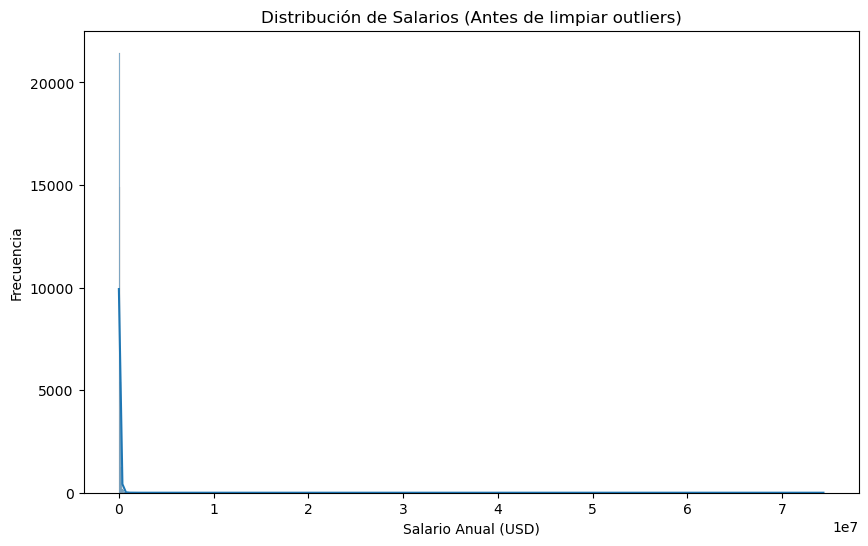

In [9]:
try:
    print("--- Analizando la distribución de Salarios (Target 'y') ---")
    
    # 1. Ver las estadísticas (min, max, media)
    print(df_so_clean['ConvertedCompYearly'].describe())

    # 2. Visualizar la distribución
    # (Esto probablemente se verá como un 'pico' en la izquierda
    # y una 'cola' larguísima hacia la derecha)
    plt.figure(figsize=(10, 6))
    sns.histplot(df_so_clean['ConvertedCompYearly'], bins=1000, kde=True)
    plt.title('Distribución de Salarios (Antes de limpiar outliers)')
    plt.xlabel('Salario Anual (USD)')
    plt.ylabel('Frecuencia')
    plt.show()

except Exception as e:
    print(f"Ocurrió un error: {e}")

In [10]:
try:
    print("--- Paso 2.5: Eliminando Outliers del Salario (Target 'y') ---")
    
    # 1. Calcular los umbrales (Percentil 5 y 95)
    q_low = df_so_clean['ConvertedCompYearly'].quantile(0.05)
    q_high = df_so_clean['ConvertedCompYearly'].quantile(0.95)

    print(f"Umbral de salario bajo (Percentil 5): ${q_low:,.2f}")
    print(f"Umbral de salario alto (Percentil 95): ${q_high:,.2f}")

    # 2. Filtrar el DataFrame
    # ¡Esta vez SÓLO nos quedamos con las filas DENTRO del rango!
    df_so_final = df_so_clean[
        (df_so_clean['ConvertedCompYearly'] >= q_low) &
        (df_so_clean['ConvertedCompYearly'] <= q_high)
    ].copy()

    print(f"\nDatos antes del filtro de outliers: {df_so_clean.shape[0]} filas")
    print(f"Datos DESPUÉS del filtro de outliers: {df_so_final.shape[0]} filas")
    
    # 3. Inspeccionar el resultado
    print("\nResumen estadístico DESPUÉS de eliminar outliers:")
    print(df_so_final['ConvertedCompYearly'].describe())

except Exception as e:
    print(f"Ocurrió un error: {e}")

--- Paso 2.5: Eliminando Outliers del Salario (Target 'y') ---
Umbral de salario bajo (Percentil 5): $6,575.90
Umbral de salario alto (Percentil 95): $229,000.00

Datos antes del filtro de outliers: 44104 filas
Datos DESPUÉS del filtro de outliers: 39693 filas

Resumen estadístico DESPUÉS de eliminar outliers:
count     39693.000000
mean      85375.804071
std       50226.347245
min        6581.000000
25%       48190.000000
50%       74963.000000
75%      116690.000000
max      229000.000000
Name: ConvertedCompYearly, dtype: float64


In [11]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np 

try:
    # --- 1. Preparación y División ---
    print("Preparando los datos finales (limpios) para el modelo...")

    # (Debemos re-definir nuestras features X e y usando el NUEVO DataFrame)
    
    # Obtener las listas de columnas de habilidades que creamos
    lang_cols = [col for col in df_so_final.columns if col.startswith('lang_')]
    db_cols = [col for col in df_so_final.columns if col.startswith('db_')]
    role_cols = [col for col in df_so_final.columns if col.startswith('role_')]
    
    FEATURES = ['YearsCode', 'EdLevel_Numeric'] + lang_cols + db_cols + role_cols
    TARGET = 'ConvertedCompYearly'

    # Crear los DataFrames X e y desde df_so_final
    X = df_so_final[FEATURES]
    y = df_so_final[TARGET]
    
    print(f"Forma de X (características): {X.shape}") # (39693, 57)
    print(f"Forma de y (objetivo): {y.shape}")

    # Dividir en Entrenamiento y Prueba
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    print(f"Tamaño de X_train (entrenamiento): {X_train.shape}")
    print(f"Tamaño de X_test (prueba): {X_test.shape}")

    # --- 2. Entrenamiento ---
    print("\nIniciando el re-entrenamiento del modelo (con datos limpios)...")
    
    # Re-inicializamos el modelo
    model_so = RandomForestRegressor(
        n_estimators=100, 
        random_state=42, 
        n_jobs=-1
    )

    # Entrenamos con los datos limpios
    model_so.fit(X_train, y_train)
    
    print("¡Modelo re-entrenado exitosamente!")

    # --- 3. Predicción ---
    print("Realizando predicciones en el set de prueba...")
    y_pred = model_so.predict(X_test)

    # --- 4. Evaluación ---
    print("Evaluando el rendimiento del modelo (limpio)...")
    
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))

    print("\n--- ¡Resultados Finales de la Evaluación! ---")
    print(f"R-cuadrado (R²): {r2:.4f}")
    print(f"Error Absoluto Medio (MAE): ${mae:,.2f}")
    print(f"Error Cuadrático Medio Raíz (RMSE): ${rmse:,.2f}")

    # --- Interpretación ---
    print("\n--- Interpretación ---")
    print(f"El modelo explica el {r2:.1%} de la varianza en los salarios.")
    print(f"En promedio, las predicciones de salario del modelo tienen un error de +/- ${mae:,.2f}.")

except Exception as e:
    print(f"Ocurrió un error durante el re-entrenamiento: {e}")

Preparando los datos finales (limpios) para el modelo...
Forma de X (características): (39693, 57)
Forma de y (objetivo): (39693,)
Tamaño de X_train (entrenamiento): (31754, 57)
Tamaño de X_test (prueba): (7939, 57)

Iniciando el re-entrenamiento del modelo (con datos limpios)...
¡Modelo re-entrenado exitosamente!
Realizando predicciones en el set de prueba...
Evaluando el rendimiento del modelo (limpio)...

--- ¡Resultados Finales de la Evaluación! ---
R-cuadrado (R²): 0.1322
Error Absoluto Medio (MAE): $36,989.27
Error Cuadrático Medio Raíz (RMSE): $46,352.18

--- Interpretación ---
El modelo explica el 13.2% de la varianza en los salarios.
En promedio, las predicciones de salario del modelo tienen un error de +/- $36,989.27.


In [12]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np 

try:
    # --- 1. Preparación y División (con Log-Transform) ---
    print("Preparando los datos (¡con Transformación Logarítmica!)...")

    # (Las 'FEATURES' siguen siendo las mismas)
    X = df_so_final[FEATURES]
    
    # ¡AQUÍ ESTÁ EL CAMBIO!
    # 1. Obtenemos 'y'
    y = df_so_final[TARGET]
    # 2. Creamos 'y_log'
    y_log = np.log1p(y)

    print(f"Forma de X: {X.shape}")
    print(f"Forma de y_log: {y_log.shape}")

    # Dividimos los datos (¡fíjate que usamos 'y_log'!)
    X_train, X_test, y_train_log, y_test_log = train_test_split(
        X, y_log, test_size=0.2, random_state=42
    )

    print(f"Tamaño de X_train: {X_train.shape}")
    print(f"TamaTño de X_test: {X_test.shape}")

    # --- 2. Entrenamiento ---
    print("\nIniciando el re-entrenamiento (modelo aprenderá a predecir el log)...")
    
    model_so.fit(X_train, y_train_log)
    
    print("¡Modelo re-entrenado exitosamente!")

    # --- 3. Predicción ---
    print("Realizando predicciones (en escala logarítmica)...")
    y_pred_log = model_so.predict(X_test)

    # --- 4. ¡Revertir la Transformación! ---
    # ¡Convertimos las predicciones y los valores reales
    # DE VUELTA a dólares para poder medirlos!
    
    y_pred_final = np.expm1(y_pred_log)
    y_test_final = np.expm1(y_test_log)

    # --- 5. Evaluación ---
    print("Evaluando el rendimiento del modelo (en dólares)...")
    
    r2 = r2_score(y_test_final, y_pred_final)
    mae = mean_absolute_error(y_test_final, y_pred_final)
    rmse = np.sqrt(mean_squared_error(y_test_final, y_pred_final))

    print("\n--- ¡Resultados Finales de la Evaluación (con Log-Transform)! ---")
    print(f"R-cuadrado (R²): {r2:.4f}")
    print(f"Error Absoluto Medio (MAE): ${mae:,.2f}")
    print(f"Error Cuadrático Medio Raíz (RMSE): ${rmse:,.2f}")

    # --- Interpretación ---
    print("\n--- Interpretación ---")
    print(f"El modelo explica el {r2:.1%} de la varianza en los salarios.")
    print(f"En promedio, las predicciones de salario del modelo tienen un error de +/- ${mae:,.2f}.")

except Exception as e:
    print(f"Ocurrió un error: {e}")

Preparando los datos (¡con Transformación Logarítmica!)...
Forma de X: (39693, 57)
Forma de y_log: (39693,)
Tamaño de X_train: (31754, 57)
TamaTño de X_test: (7939, 57)

Iniciando el re-entrenamiento (modelo aprenderá a predecir el log)...
¡Modelo re-entrenado exitosamente!
Realizando predicciones (en escala logarítmica)...
Evaluando el rendimiento del modelo (en dólares)...

--- ¡Resultados Finales de la Evaluación (con Log-Transform)! ---
R-cuadrado (R²): 0.0832
Error Absoluto Medio (MAE): $36,198.59
Error Cuadrático Medio Raíz (RMSE): $47,641.00

--- Interpretación ---
El modelo explica el 8.3% de la varianza en los salarios.
En promedio, las predicciones de salario del modelo tienen un error de +/- $36,198.59.


In [13]:
try:
    print("--- Paso 2.2b: Añadiendo Habilidades de Nube (¡El paso que faltaba!) ---")

    # (Asegúrate de estar usando 'df_so_clean', el de 44,104 filas)
    
    # "Aplanar" (fillna('') maneja los nulos que vimos)
    all_platforms = df_so_clean['PlatformHaveWorkedWith'].fillna('').str.split(';').explode()
    
    # Quitar el valor vacío ('')
    all_platforms = all_platforms[all_platforms != '']
    
    # Obtener el Top 15
    top_15_platforms = all_platforms.value_counts().head(15).index.tolist()

    print(f"\nTop 15 Plataformas: {top_15_platforms}")
    print("Creando columnas binarias para el Top 15 de plataformas...")

    for platform in top_15_platforms:
        col_name = f"platform_{platform.replace('/', '_').replace(' ', '_').replace('.', '_')}"
        df_so_clean[col_name] = df_so_clean['PlatformHaveWorkedWith'].fillna('').apply(
            lambda x: 1 if platform in x else 0
        )
        
    print("¡Columnas de plataformas creadas!")
    print(f"Dimensiones de df_so_clean ahora: {df_so_clean.shape}") # Debería ser (44104, 155)

except Exception as e:
    print(f"Ocurrió un error: {e}")

--- Paso 2.2b: Añadiendo Habilidades de Nube (¡El paso que faltaba!) ---

Top 15 Plataformas: ['Amazon Web Services (AWS)', 'Microsoft Azure', 'Google Cloud', 'Cloudflare', 'Digital Ocean', 'Firebase', 'Heroku', 'Vercel', 'Netlify', 'VMware', 'Hetzner', 'Linode, now Akamai', 'OVH', 'Managed Hosting', 'OpenShift']
Creando columnas binarias para el Top 15 de plataformas...
¡Columnas de plataformas creadas!
Dimensiones de df_so_clean ahora: (44104, 155)


In [14]:
# --- Re-Entrenamiento (Versión Final, con Nube) ---
try:
    # --- 1. Filtrar Outliers (como hicimos antes) ---
    q_low = df_so_clean['ConvertedCompYearly'].quantile(0.05)
    q_high = df_so_clean['ConvertedCompYearly'].quantile(0.95)
    df_so_final = df_so_clean[
        (df_so_clean['ConvertedCompYearly'] >= q_low) &
        (df_so_clean['ConvertedCompYearly'] <= q_high)
    ].copy()
    print(f"Datos limpios y con features: {df_so_final.shape[0]} filas") # 39,693 filas

    # --- 2. Preparación y División (¡con 'platform_') ---
    print("Preparando los datos (¡con Habilidades de Nube!)...")
    
    lang_cols = [col for col in df_so_final.columns if col.startswith('lang_')]
    db_cols = [col for col in df_so_final.columns if col.startswith('db_')]
    role_cols = [col for col in df_so_final.columns if col.startswith('role_')]
    platform_cols = [col for col in df_so_final.columns if col.startswith('platform_')] # ¡LA NUEVA LISTA!
    
    # ¡Nuestra lista de features ahora es mucho más potente!
    FEATURES = ['YearsCode', 'EdLevel_Numeric'] + lang_cols + db_cols + role_cols + platform_cols
    TARGET = 'ConvertedCompYearly'

    X = df_so_final[FEATURES]
    y_log = np.log1p(df_so_final[TARGET]) # Usamos la transformación Log

    print(f"Forma de X (con Nube): {X.shape}") # Debería tener ~72 features
    
    X_train, X_test, y_train_log, y_test_log = train_test_split(
        X, y_log, test_size=0.2, random_state=42
    )

    # --- 3. Entrenamiento ---
    print("\nIniciando re-entrenamiento (con Nube)...")
    model_so.fit(X_train, y_train_log)
    print("¡Modelo re-entrenado!")

    # --- 4. Predicción y Evaluación ---
    y_pred_log = model_so.predict(X_test)
    y_pred_final = np.expm1(y_pred_log)
    y_test_final = np.expm1(y_test_log)

    r2 = r2_score(y_test_final, y_pred_final)
    mae = mean_absolute_error(y_test_final, y_pred_final)

    print("\n--- ¡Resultados Finales (con Habilidades de Nube)! ---")
    print(f"R-cuadrado (R²): {r2:.4f}")
    print(f"Error Absoluto Medio (MAE): ${mae:,.2f}")
    print(f"El modelo (con Nube) explica el {r2:.1%} de la varianza.")

except Exception as e:
    print(f"Ocurrió un error: {e}")

Datos limpios y con features: 39693 filas
Preparando los datos (¡con Habilidades de Nube!)...
Forma de X (con Nube): (39693, 72)

Iniciando re-entrenamiento (con Nube)...
¡Modelo re-entrenado!

--- ¡Resultados Finales (con Habilidades de Nube)! ---
R-cuadrado (R²): 0.1236
Error Absoluto Medio (MAE): $35,228.53
El modelo (con Nube) explica el 12.4% de la varianza.


In [15]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np 

try:
    # --- 1. Cargar el dataset de Stack Overflow (si es necesario) ---
    # Si 'df_so_clean' (44,104 filas) no está en memoria, re-ejecuta
    # los pasos 2.2, 2.3 y 2.4 de la Misión 2 para crearlo.
    # Asumiremos que 'df_so_clean' (44,104 filas) SÍ está en memoria.
    
    print(f"Punto de partida: df_so_clean con {df_so_clean.shape[0]} filas.")

    # --- 2. Añadir 'Country' (Top 10) ---
    print("\nAñadiendo 'Country' (Top 10)...")
    
    # Primero, necesitamos la columna 'Country' en nuestro df limpio
    # (El 'df_so_clean' ya debería tenerlo, pero si no, lo traemos)
    if 'Country' not in df_so_clean.columns:
        df_so_clean['Country'] = df_so['Country'] # Traer la columna del df original

    # Manejar nulos en 'Country'
    df_so_clean['Country'] = df_so_clean['Country'].fillna('Other')
    
    # Encontrar el Top 10 de países
    top_10_countries = df_so_clean['Country'].value_counts().head(10).index.tolist()
    print(f"Top 10 Países: {top_10_countries}")

    # Binarizar solo el Top 10
    for country in top_10_countries:
        col_name = f"country_{country.replace(' ', '_')}"
        df_so_clean[col_name] = df_so_clean['Country'].apply(lambda x: 1 if x == country else 0)
    
    # --- 3. Añadir 'OrgSize' (Tamaño de Empresa) ---
    print("\nAñadiendo 'OrgSize'...")

    if 'OrgSize' not in df_so_clean.columns:
        df_so_clean['OrgSize'] = df_so['OrgSize'] # Traer la columna
        
    # Crear el mapa ordinal
    # (Obtenido de la documentación de la encuesta de SO)
    org_size_map = {
        'Just me - I am a freelancer, sole proprietor, etc.': 1,
        '2 to 9 employees': 2,
        '10 to 19 employees': 3,
        '20 to 99 employees': 4,
        '100 to 499 employees': 5,
        '500 to 999 employees': 6,
        '1,000 to 4,999 employees': 7,
        '5,000 to 9,999 employees': 8,
        '10,000 or more employees': 9,
        np.nan: 0, # Tratar nulos como 'Desconocido'
        'I don’t know': 0
    }
    
    df_so_clean['OrgSize_Numeric'] = df_so_clean['OrgSize'].map(org_size_map).fillna(0)
    print("Mapeo de 'OrgSize' a 'OrgSize_Numeric' completado.")
    
    # --- 4. Filtro de Outliers (como antes) ---
    print("\nFiltrando outliers de salario...")
    q_low = df_so_clean['ConvertedCompYearly'].quantile(0.05)
    q_high = df_so_clean['ConvertedCompYearly'].quantile(0.95)
    df_so_final = df_so_clean[
        (df_so_clean['ConvertedCompYearly'] >= q_low) &
        (df_so_clean['ConvertedCompYearly'] <= q_high)
    ].copy()
    print(f"Datos finales listos para entrenar: {df_so_final.shape[0]} filas") # ~39k filas

    # --- 5. Preparación y División (¡CON TODAS LAS FEATURES!) ---
    print("\nPreparando los datos (CON PAÍS Y TAMAÑO)...")
    
    lang_cols = [col for col in df_so_final.columns if col.startswith('lang_')]
    db_cols = [col for col in df_so_final.columns if col.startswith('db_')]
    role_cols = [col for col in df_so_final.columns if col.startswith('role_')]
    platform_cols = [col for col in df_so_final.columns if col.startswith('platform_')]
    country_cols = [col for col in df_so_final.columns if col.startswith('country_')] # ¡NUEVO!

    # ¡LA LISTA FINAL DE FEATURES!
    FEATURES = ['YearsCode', 'EdLevel_Numeric', 'OrgSize_Numeric'] + \
               lang_cols + db_cols + role_cols + platform_cols + country_cols
    TARGET = 'ConvertedCompYearly'

    X = df_so_final[FEATURES]
    y_log = np.log1p(df_so_final[TARGET]) # Seguimos usando la transformación Log

    print(f"Forma de X (¡FINAL!): {X.shape}") # Debería tener ~83 features
    
    X_train, X_test, y_train_log, y_test_log = train_test_split(
        X, y_log, test_size=0.2, random_state=42
    )

    # --- 6. Entrenamiento y Evaluación ---
    print("\nIniciando entrenamiento final...")
    
    # Re-inicializamos el modelo
    model_so = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    model_so.fit(X_train, y_train_log)
    print("¡Modelo entrenado!")

    y_pred_log = model_so.predict(X_test)
    y_pred_final = np.expm1(y_pred_log)
    y_test_final = np.expm1(y_test_log)

    r2 = r2_score(y_test_final, y_pred_final)
    mae = mean_absolute_error(y_test_final, y_pred_final)

    print("\n--- ¡Resultados del SPRINT FINAL! ---")
    print(f"R-cuadrado (R²): {r2:.4f}")
    print(f"Error Absoluto Medio (MAE): ${mae:,.2f}")
    print(f"El modelo (con País y Tamaño) explica el {r2:.1%} de la varianza.")

except Exception as e:
    print(f"Ocurrió un error: {e}")

Punto de partida: df_so_clean con 44104 filas.

Añadiendo 'Country' (Top 10)...
Top 10 Países: ['United States of America', 'Germany', 'United Kingdom of Great Britain and Northern Ireland', 'Canada', 'India', 'France', 'Netherlands', 'Poland', 'Brazil', 'Australia']

Añadiendo 'OrgSize'...
Mapeo de 'OrgSize' a 'OrgSize_Numeric' completado.

Filtrando outliers de salario...
Datos finales listos para entrenar: 39693 filas

Preparando los datos (CON PAÍS Y TAMAÑO)...
Forma de X (¡FINAL!): (39693, 83)

Iniciando entrenamiento final...
¡Modelo entrenado!

--- ¡Resultados del SPRINT FINAL! ---
R-cuadrado (R²): 0.5204
Error Absoluto Medio (MAE): $25,158.79
El modelo (con País y Tamaño) explica el 52.0% de la varianza.


In [16]:
import joblib
import os

try:
    # Definir el nombre del archivo
    model_filename = 'salary_prediction_model.joblib'

    # Guardar el modelo
    joblib.dump(model_so, model_filename)

    print(f"¡Modelo de salario guardado exitosamente como '{model_filename}'!")
    print(f"Tamaño del archivo: {os.path.getsize(model_filename) / (1024*1024):.2f} MB")

except Exception as e:
    print(f"Ocurrió un error al guardar el modelo: {e}")

¡Modelo de salario guardado exitosamente como 'salary_prediction_model.joblib'!
Tamaño del archivo: 266.03 MB


In [17]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np 
from xgboost import XGBRegressor  # <--- ¡CAMBIO 1!

try:
    # --- 1. Preparación y División (¡CON TODAS LAS FEATURES!) ---
    print("Preparando los datos (CON PAÍS Y TAMAÑO)...")
    
    # Asumimos que 'df_so_final' (39,693 filas) está en memoria
    
    lang_cols = [col for col in df_so_final.columns if col.startswith('lang_')]
    db_cols = [col for col in df_so_final.columns if col.startswith('db_')]
    role_cols = [col for col in df_so_final.columns if col.startswith('role_')]
    platform_cols = [col for col in df_so_final.columns if col.startswith('platform_')]
    country_cols = [col for col in df_so_final.columns if col.startswith('country_')]

    FEATURES = ['YearsCode', 'EdLevel_Numeric', 'OrgSize_Numeric'] + \
               lang_cols + db_cols + role_cols + platform_cols + country_cols
    TARGET = 'ConvertedCompYearly'

    X = df_so_final[FEATURES]
    y_log = np.log1p(df_so_final[TARGET]) # Seguimos usando la transformación Log

    print(f"Forma de X (¡FINAL!): {X.shape}")
    
    X_train, X_test, y_train_log, y_test_log = train_test_split(
        X, y_log, test_size=0.2, random_state=42
    )

    # --- 6. Entrenamiento y Evaluación (con XGBoost) ---
    print("\nIniciando entrenamiento con XGBoost...")
    
    # --- ¡CAMBIO 2! ---
    # Re-inicializamos el modelo usando XGBRegressor
    model_so = XGBRegressor(
        n_estimators=100,      # 100 árboles (buen inicio)
        learning_rate=0.1,   # Tasa de aprendizaje
        random_state=42, 
        n_jobs=-1
    )
    
    model_so.fit(X_train, y_train_log)
    print("¡Modelo XGBoost entrenado!")

    y_pred_log = model_so.predict(X_test)
    y_pred_final = np.expm1(y_pred_log)
    y_test_final = np.expm1(y_test_log)

    r2 = r2_score(y_test_final, y_pred_final)
    mae = mean_absolute_error(y_test_final, y_pred_final)

    print("\n--- ¡Resultados con XGBoost! ---")
    print(f"R-cuadrado (R²): {r2:.4f}")
    print(f"Error Absoluto Medio (MAE): ${mae:,.2f}")
    print(f"El modelo (XGBoost) explica el {r2:.1%} de la varianza.")

except Exception as e:
    print(f"Ocurrió un error: {e}")

Preparando los datos (CON PAÍS Y TAMAÑO)...
Forma de X (¡FINAL!): (39693, 83)

Iniciando entrenamiento con XGBoost...
¡Modelo XGBoost entrenado!

--- ¡Resultados con XGBoost! ---
R-cuadrado (R²): 0.5422
Error Absoluto Medio (MAE): $24,463.94
El modelo (XGBoost) explica el 54.2% de la varianza.
